In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/home/icb/dominik.klein/mambaforge/envs/cfp/lib/python3.11/site-packages/optuna/study/_optimize.py:29: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from optuna import progress_bar as pbar_module


In [2]:
data_dir = "/lustre/groups/ml01/workspace/cell_flow_zebrafish/results/single_condition/cell_type_proportion"
output_dir = "/lustre/groups/ml01/workspace/cell_flow_zebrafish/results/single_condition/cell_type_proportion_downstream"

In [3]:
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/zebrafish_new/zebrafish_processed.h5ad")

In [4]:
df_counts = adata.obs.groupby(["condition","cell_type_broad"]).size().to_frame(name="n_cells")


/tmp/ipykernel_1847008/2853154197.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_counts = adata.obs.groupby(["condition","cell_type_broad"]).size().to_frame(name="n_cells")


In [5]:
df_counts = df_counts.reset_index()

In [6]:
ood_conditions = ['zc4h2_control_24','met_control_36','tfap2a_control_72','hgfa_control_48','tfap2a_foxd3_72','noto_control_18','cdx4_cdx1a_36','epha4a_control_48','mafba_control_36','tbx16_msgn1_24','noto_control_24','smo_control_18','hand2_control_24','noto_control_36','egr2b_control_36','cdx4_control_18','tfap2a_control_36','foxi1_control_72','egr2b_control_24','cdx4_control_36','zc4h2_control_36','hoxb1a_control_48','tfap2a_foxd3_36','tbx16_tbx16l_24','smo_control_36','mafba_control_18','hgfa_control_72','tbx16_control_18','mafba_control_24','tbx1_control_36','zc4h2_control_48','wnt3a_wnt8_36','foxi1_control_48','smo_control_24','noto_control_48','mafba_control_48','tfap2a_control_48','hand2_control_48','egr2b_control_48','phox2a_control_48','tbx1_control_48','tbx16_msgn1_36','foxd3_control_72','wnt3a_wnt8_24','egr2b_control_18','wnt3a_wnt8_18','met_control_72','phox2a_control_36','epha4a_control_24','foxd3_control_36','tfap2a_foxd3_48','hand2_control_36','cdx4_cdx1a_24','hgfa_control_36','tbx16_tbx16l_18','tbxta_control_36','cdx4_control_24','foxd3_control_48','met_control_48','tbx1_control_24','epha4a_control_36','cdx4_cdx1a_18','tbx16_control_36','tbx16_tbx16l_36','tbx16_control_24','tbxta_control_24','tbx16_msgn1_18','epha4a_control_18','tbxta_control_18','hoxb1a_control_36','hoxb1a_control_24']
      

In [7]:
spearman_corrs = {}
pearson_corrs = {}
max_logratios = {}
dfs = []
for ood_cond in ood_conditions:
    csv_file = [el for el in os.listdir(data_dir) if ((ood_cond in el) and ("csv" in el))]
    if len(csv_file)==0:
        continue
    assert len(csv_file) == 1
    df = pd.read_csv(os.path.join(data_dir, csv_file[0]))
    spearman_corrs[ood_cond] = df[["logratio_true", "logratio_pred"]].corr("spearman").iloc[0,1]
    pearson_corrs[ood_cond] = df[["logratio_true", "logratio_pred"]].corr("pearson").iloc[0,1]
    max_logratios[ood_cond] = np.abs(df["logratio_true"]).max()
    df["condition"] = f"{ood_cond}"
    dfs.append(df)

In [8]:
df_pred = pd.concat(dfs)
df_pred["gene_target"] = df_pred.apply(lambda x: "_".join(x["condition"].split("_")[:2]), axis=1)
df_pred["timepoint"] = df_pred.apply(lambda x: int(x["condition"].split("_")[-1]), axis=1)

In [9]:
df_pred.head()

,cell_type_broad_transfer,ratio_pred,ratio_true,logratio_true,logratio_pred,condition,gene_target,timepoint
0,periderm,1.182168,1.349712,0.432652,0.241436,zc4h2_control_24,zc4h2_control,24
1,mature fast muscle,1.177825,1.242196,0.312892,0.236125,zc4h2_control_24,zc4h2_control,24
2,connective tissue-meninges-dermal FB,1.046386,0.899433,-0.152912,0.065415,zc4h2_control_24,zc4h2_control,24
3,neural progenitor (hindbrain),0.864279,0.775667,-0.366491,-0.210431,zc4h2_control_24,zc4h2_control,24
4,mature slow muscle,0.975546,1.205383,0.269492,-0.035718,zc4h2_control_24,zc4h2_control,24


In [10]:
df_baseline = pd.read_csv("/lustre/groups/ml01/workspace/cell_flow_zebrafish/results/single_condition/cell_type_proportion_baseline/all_single_oligo_ratios.csv", index_col=0)


In [11]:
df_baseline["cell_type_broad_transfer"] = df_baseline.index
df_baseline = df_baseline.rename(columns={"logratio_oligo": "logratio_pred", "ratio_olgo": "logratio_pred"})
df_baseline["mode"] = "single_oligo"
df_pred["mode"] = "CellFlow"

In [12]:
spearman_corrs = {}
pearson_corrs = {}
max_logratios = {}
dfs = []
for ood_cond in ood_conditions:
    csv_file = [el for el in os.listdir(data_dir) if ((ood_cond in el) and ("csv" in el))]
    if len(csv_file)==0:
        continue
    assert len(csv_file) == 1
    df = pd.read_csv(os.path.join("/lustre/groups/ml01/workspace/cell_flow_zebrafish/results/single_condition/cell_type_proportion_mean_model", csv_file[0]))
    spearman_corrs[ood_cond] = df[["logratio_true", "logratio_pred"]].corr("spearman").iloc[0,1]
    pearson_corrs[ood_cond] = df[["logratio_true", "logratio_pred"]].corr("pearson").iloc[0,1]
    max_logratios[ood_cond] = np.abs(df["logratio_true"]).max()
    df["condition"] = f"{ood_cond}"
    dfs.append(df)
df_mean = pd.concat(dfs)
df_mean["gene_target"] = df_mean.apply(lambda x: "_".join(x["condition"].split("_")[:2]), axis=1)
df_mean["timepoint"] = df_mean.apply(lambda x: int(x["condition"].split("_")[-1]), axis=1)

In [13]:
df_mean.head()

,cell_type_broad_transfer,ratio_pred,ratio_true,logratio_true,logratio_pred,condition,gene_target,timepoint
0,periderm,0.988935,1.349712,0.432652,-0.016052,zc4h2_control_24,zc4h2_control,24
1,mature fast muscle,1.022607,1.242196,0.312892,0.032252,zc4h2_control_24,zc4h2_control,24
2,neural progenitor (hindbrain),0.985573,0.775667,-0.366491,-0.020965,zc4h2_control_24,zc4h2_control,24
3,connective tissue-meninges-dermal FB,1.019674,0.899433,-0.152912,0.028109,zc4h2_control_24,zc4h2_control,24
4,mature slow muscle,1.003983,1.205383,0.269492,0.005735,zc4h2_control_24,zc4h2_control,24


In [14]:
spearman_corrs = {}
pearson_corrs = {}
max_logratios = {}
dfs = []
for ood_cond in ood_conditions:
    csv_file = [el for el in os.listdir(data_dir) if ((ood_cond in el) and ("csv" in el))]
    if len(csv_file)==0:
        continue
    assert len(csv_file) == 1
    df = pd.read_csv(os.path.join("/lustre/groups/ml01/workspace/cell_flow_zebrafish/results/single_condition/cell_type_proportion_closest_embedding", csv_file[0]))
    spearman_corrs[ood_cond] = df[["logratio_true", "logratio_pred"]].corr("spearman").iloc[0,1]
    pearson_corrs[ood_cond] = df[["logratio_true", "logratio_pred"]].corr("pearson").iloc[0,1]
    max_logratios[ood_cond] = np.abs(df["logratio_true"]).max()
    df["condition"] = f"{ood_cond}"
    dfs.append(df)
df_cl = pd.concat(dfs)
df_cl["gene_target"] = df_cl.apply(lambda x: "_".join(x["condition"].split("_")[:2]), axis=1)
df_cl["timepoint"] = df_cl.apply(lambda x: int(x["condition"].split("_")[-1]), axis=1)

In [15]:
df_cl.head()

,cell_type_broad_transfer,ratio_pred,ratio_true,logratio_true,logratio_pred,condition,gene_target,timepoint
0,periderm,1.325555,1.349712,0.432652,0.406596,zc4h2_control_24,zc4h2_control,24
1,mature fast muscle,1.467595,1.242196,0.312892,0.553454,zc4h2_control_24,zc4h2_control,24
2,connective tissue-meninges-dermal FB,0.874504,0.899433,-0.152912,-0.193463,zc4h2_control_24,zc4h2_control,24
3,basal cell,26.761978,1.279608,0.355702,4.742113,zc4h2_control_24,zc4h2_control,24
4,mature slow muscle,0.727513,1.205383,0.269492,-0.458956,zc4h2_control_24,zc4h2_control,24


In [24]:
df_counts["condition"].value_counts()
df_counts_no_control = df_counts[~df_counts["condition"].isin(("control_control_18", "control_control_24", "control_control_36", "control_control_48", "control_control_72"))]


In [25]:
df_corrs_conditions = pd.DataFrame(columns=["cell_type_broad", "pearson", "spearman", "method", "n_cells_mean", "n_cells_var"])

i=0


for cell_type in adata.obs["cell_type_broad"].unique():
    df_pred_red = df_pred[(df_pred["cell_type_broad_transfer"]==cell_type) & (df_pred["gene_target"]!="control_control")]
    df_baseline_red = df_baseline[(df_baseline["cell_type_broad_transfer"]==cell_type) & (df_baseline["gene_target"]!="control_control")]
    df_mean_red = df_mean[(df_mean["cell_type_broad_transfer"]==cell_type) & (df_mean["gene_target"]!="control_control")]
    df_cl_red = df_cl[(df_cl["cell_type_broad_transfer"]==cell_type) & (df_cl["gene_target"]!="control_control")]
    pearson_pred = df_pred_red[["logratio_true", "logratio_pred"]].corr(method="pearson").iloc[0,1]
    pearson_baseline = df_baseline_red[["logratio_true", "logratio_pred"]].corr(method="pearson").iloc[0,1]
    pearson_mean = df_mean_red[["logratio_true", "logratio_pred"]].corr(method="pearson").iloc[0,1]
    pearson_cl = df_cl_red[["logratio_true", "logratio_pred"]].corr(method="pearson").iloc[0,1]
    spearman_pred = df_pred_red[["logratio_true", "logratio_pred"]].corr(method="spearman").iloc[0,1]
    spearman_baseline = df_baseline_red[["logratio_true", "logratio_pred"]].corr(method="spearman").iloc[0,1]
    spearman_mean = df_mean_red[["logratio_true", "logratio_pred"]].corr(method="spearman").iloc[0,1]
    spearman_cl = df_cl_red[["logratio_true", "logratio_pred"]].corr(method="spearman").iloc[0,1]
    n_cells_mean = df_counts_no_control[df_counts_no_control["cell_type_broad"]==cell_type]["n_cells"].mean()
    n_cells_var = df_counts_no_control[df_counts_no_control["cell_type_broad"]==cell_type]["n_cells"].std()
    df_corrs_conditions.loc[len(df_corrs_conditions)] = [cell_type, pearson_pred, spearman_pred, "cellflow", n_cells_mean, n_cells_var]
    df_corrs_conditions.loc[len(df_corrs_conditions)] = [cell_type, pearson_baseline, spearman_baseline, "single_oligo", n_cells_mean, n_cells_var]
    df_corrs_conditions.loc[len(df_corrs_conditions)] = [cell_type, pearson_mean, spearman_mean, "mean", n_cells_mean, n_cells_var]
    df_corrs_conditions.loc[len(df_corrs_conditions)] = [cell_type, pearson_cl, spearman_cl, "cl", n_cells_mean, n_cells_var]
    
    
    i+=4

    

<Axes: xlabel='method', ylabel='pearson'>

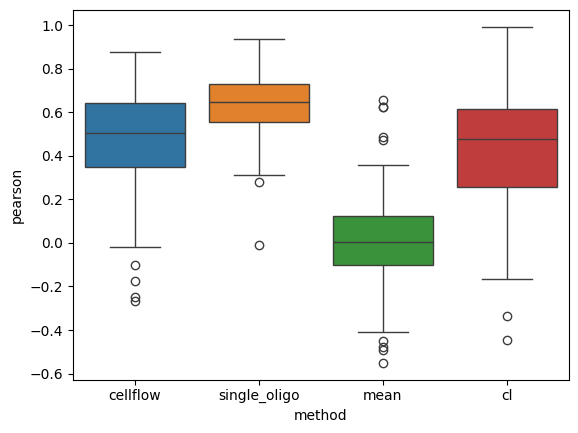

In [26]:
sns.boxplot(df_corrs_conditions, x="method", y="pearson", hue="method")

In [27]:
df_corrs_conditions.head()

,cell_type_broad,pearson,spearman,method,n_cells_mean,n_cells_var
0,head mesenchyme/PA cartilage,0.373862,0.431507,cellflow,267.014085,140.881560
1,head mesenchyme/PA cartilage,0.686513,0.705192,single_oligo,267.014085,140.881560
2,head mesenchyme/PA cartilage,-0.154115,-0.071216,mean,267.014085,140.881560
3,head mesenchyme/PA cartilage,0.584481,0.563873,cl,267.014085,140.881560
4,intestine,0.538647,0.536654,cellflow,307.253521,353.132784


In [28]:
df_corrs_conditions["quantile_bin_n_cells"] = pd.qcut(df_corrs_conditions["n_cells_mean"], q=4, labels=["Q1","Q2","Q3","Q4"])

In [31]:
df_corrs_conditions.groupby("quantile_bin_n_cells")["n_cells_mean"].median()

/tmp/ipykernel_1847008/3438169878.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_corrs_conditions.groupby("quantile_bin_n_cells")["n_cells_mean"].median()


quantile_bin_n_cells
Q1     17.394366
Q2     83.971831
Q3    192.676056
Q4    566.352113
Name: n_cells_mean, dtype: float64

<Axes: xlabel='method', ylabel='pearson'>

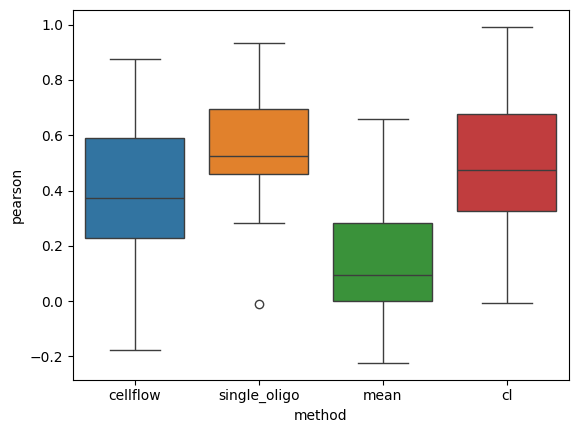

In [32]:
sns.boxplot(df_corrs_conditions[df_corrs_conditions["quantile_bin_n_cells"]=="Q1"], x="method", y="pearson", hue="method")

In [33]:
df_red = df_corrs_conditions[df_corrs_conditions["method"]=="single_oligo"]
df_red["quantile_pert_strength"] = pd.qcut(df_red["pearson"], q=4, labels=["Q1","Q2","Q3","Q4"])

/tmp/ipykernel_1847008/2950356293.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_red["quantile_pert_strength"] = pd.qcut(df_red["pearson"], q=4, labels=["Q1","Q2","Q3","Q4"])


In [34]:
df_red.head()

,cell_type_broad,pearson,spearman,method,n_cells_mean,n_cells_var,quantile_bin_n_cells,quantile_pert_strength
1,head mesenchyme/PA cartilage,0.686513,0.705192,single_oligo,267.014085,140.881560,Q3,Q3
5,intestine,0.707692,0.688817,single_oligo,307.253521,353.132784,Q3,Q3
9,basal cell,0.480572,0.589416,single_oligo,1253.478873,1277.818374,Q4,Q1
13,neural progenitor (hindbrain R7/8),0.567078,0.615306,single_oligo,385.732394,298.703386,Q4,Q2
17,"neurons (differentiating, contains peripheral)",0.698514,0.707026,single_oligo,658.676056,572.491791,Q4,Q3


In [35]:
mapping = dict(zip(df_red["cell_type_broad"], df_red["quantile_pert_strength"]))

In [36]:
df_corrs_conditions["quantile_pert_strength"] = df_corrs_conditions["cell_type_broad"].map(mapping)

<Axes: xlabel='method', ylabel='pearson'>

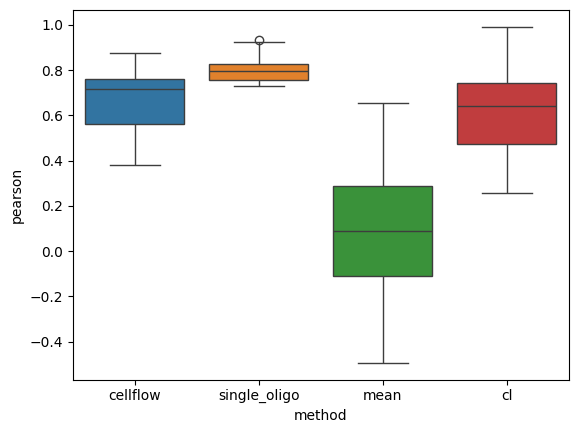

In [37]:
sns.boxplot(df_corrs_conditions[df_corrs_conditions["quantile_pert_strength"]=="Q4"], x="method", y="pearson", hue="method")

In [38]:
df_corrs_conditions.groupby(["method", "quantile_bin_n_cells"])["pearson"].mean()

/tmp/ipykernel_1847008/1099262837.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_corrs_conditions.groupby(["method", "quantile_bin_n_cells"])["pearson"].mean()


method        quantile_bin_n_cells
cellflow      Q1                      0.385260
              Q2                      0.451206
              Q3                      0.480863
              Q4                      0.548669
cl            Q1                      0.493885
              Q2                      0.440319
              Q3                      0.423756
              Q4                      0.334664
mean          Q1                      0.157996
              Q2                      0.009989
              Q3                      0.008344
              Q4                     -0.059605
single_oligo  Q1                      0.542247
              Q2                      0.637285
              Q3                      0.669240
              Q4                      0.705269
Name: pearson, dtype: float64

In [29]:
df_corrs_conditions.to_csv(os.path.join(output_dir, "corrs_conditions_all.csv"))

Make statistical tests

In [44]:
cell_types

array(['head mesenchyme/PA cartilage', 'intestine', 'basal cell',
       'neural progenitor (hindbrain R7/8)',
       'neurons (differentiating, contains peripheral)',
       'mature fast muscle', 'pharyngeal arch (early)',
       'mature slow muscle', 'retinal neuron',
       'neurons (gabaergic, glutamatergic)',
       'neural progenitor (diencephalon/telencephalon)',
       'endothelium (dorsal aorta)', 'periderm', 'eye, optic cup',
       'retinal pigmented epithelium (early)',
       'head mesenchyme (maybe ventral, hand2+)',
       'support cells/otic vesicle', 'neural progenitor (MHB)',
       'neural progenitor (hindbrain)', 'ionocyte/goblet cell',
       'connective tissue-meninges-dermal FB', 'primordial germ cell',
       'posterior lateral line primordium',
       'pectoral fin bud (osteoblast+)',
       'endothelium (vein + early artery)', 'notochord', 'fin fold',
       'head mesenchyme', 'differentiating neuron 1',
       'cranial neural crest', 'neuromast support cell',

In [65]:
df_corrs_cf = df_corrs_conditions[df_corrs_conditions["method"] == "cellflow"]
df_corrs_cf = df_corrs_cf.set_index("cell_type_broad")
vals_cellflow = df_corrs_cf["pearson"]
for method in df_corrs_conditions["method"].unique():
    df_other = df_corrs_conditions[df_corrs_conditions["method"]==method]
    df_other = df_other.set_index("cell_type_broad")
    vals_other = df_other.loc[df_corrs_cf.index]["pearson"]
    mask = ~np.isnan(vals_cellflow.values) & ~np.isnan(vals_other.values)
    a_clean = vals_cellflow[mask]
    b_clean = vals_other[mask]
    t_stat, p_val = stats.ttest_rel(a_clean, b_clean)
    print("paired", method, t_stat, p_val)

paired cellflow nan nan
unpaired cellflow 0.0 1.0
paired single_oligo -7.913278145241011 3.6795915594009195e-12
unpaired single_oligo -6.01713521896999 1.1600700319346555e-08
paired mean 13.913541074833834 1.1890960391431407e-24
unpaired mean 13.042118805536218 3.604378326101706e-28
paired cl 1.3767648610686765 0.1717221024360145
unpaired cl 1.1479060687130602 0.25242532844086457


In [67]:
df_corrs_conditions_red

,cell_type_broad,pearson,spearman,method,n_cells_mean,n_cells_var,quantile_bin_n_cells,quantile_pert_strength
84,primordial germ cell,0.229701,0.256020,cellflow,17.239437,13.971875,Q1,Q1
85,primordial germ cell,0.552271,0.523877,single_oligo,17.239437,13.971875,Q1,Q1
86,primordial germ cell,0.106270,0.047506,mean,17.239437,13.971875,Q1,Q1
87,primordial germ cell,0.324874,0.385752,cl,17.239437,13.971875,Q1,Q1
156,vascular smooth muscle,0.409932,0.280237,cellflow,24.169014,85.296288,Q1,Q4
...,...,...,...,...,...,...,...,...
399,enveloping layer (EVL),NaN,NaN,cl,0.239437,0.869561,Q1,Q1
400,"mineralized tissue, bone",NaN,NaN,cellflow,0.028169,0.166633,Q1,NaN
401,"mineralized tissue, bone",NaN,NaN,single_oligo,0.028169,0.166633,Q1,NaN
402,"mineralized tissue, bone",NaN,NaN,mean,0.028169,0.166633,Q1,NaN


In [72]:
len(vals_cellflow), len(vals_other)

(26, 101)

In [74]:
len(df_corrs_conditions_red), len(df_other)

(104, 26)

In [76]:
df_corrs_cf = df_corrs_conditions[df_corrs_conditions["method"] == "cellflow"]
df_corrs_cf = df_corrs_cf.set_index("cell_type_broad")

for ct_size in ["Q1", "Q2", "Q3", "Q4"]:
    df_corrs_conditions_red = df_corrs_conditions[df_corrs_conditions["quantile_bin_n_cells"]==ct_size]
    vals_cellflow = df_corrs_cf[df_corrs_cf["quantile_bin_n_cells"]==ct_size]["pearson"]
    for method in df_corrs_conditions["method"].unique():
        if method=="cellflow":
            continue
        df_other = df_corrs_conditions_red[df_corrs_conditions_red["method"]==method]
        df_other = df_other.set_index("cell_type_broad")
        vals_other = df_other.loc[vals_cellflow.index]["pearson"]
        mask = ~np.isnan(vals_cellflow.values) & ~np.isnan(vals_other.values)
        a_clean = vals_cellflow[mask]
        b_clean = vals_other[mask]
        t_stat, p_val = stats.ttest_rel(a_clean, b_clean)
        print("paired", ct_size, method, t_stat, p_val)

paired Q1 single_oligo -3.2053000339521445 0.003791710928798056
paired Q1 mean 3.908553351613258 0.0008711850050580609
paired Q1 cl -2.170646738883246 0.0405291074740482
paired Q2 single_oligo -3.2756219889169533 0.003196342697334033
paired Q2 mean 7.827534480389424 4.631446048041185e-08
paired Q2 cl 0.17020699670941686 0.8662740382573849
paired Q3 single_oligo -5.063470545851382 3.539554553691946e-05
paired Q3 mean 8.314436562358754 1.5843821581890547e-08
paired Q3 cl 1.1188417581669445 0.27428134776608254
paired Q4 single_oligo -5.7275519083090956 6.6823694750647075e-06
paired Q4 mean 9.944664104884213 5.477573166610695e-10
paired Q4 cl 3.375346876762134 0.002504742300878431
